# Laptop1 vs laptop2 — the compare session

`compare/run_compare.sh s1` replays one fixed order file on each machine: 50 SQLStorm StackOverflow
queries (10 per warm 1-copy time band, 0.1–6 s) and 4 synthetic probes (CPU, hash join / memory
latency, scan / memory bandwidth, sort), × 6 rounds, each round a fresh shuffle — 324 entries. Per entry:
cold start (drop caches + restart), 40–60 °C thermal gate, 2 warm-ups, a 5 s idle baseline, then a
1-copy and a 16-copy batch, clock pinned at 2.5 GHz, same PostgreSQL testing parameters. Both machines
are Dell Latitude 7490s with an i5-8350U.

| machine | host | session |
|---|---|---|
| laptop1 | `user01` | `compare_user01_s1_20261002T111803Z` |
| laptop2 | `server001` | `compare_server001_s1_20261004T161823Z` |

Laptop1 also holds a 6-entry smoke test (`smoke_compare_user01_smoke_…`), not used here.
Energy per execution is the slope `(E16 − E1) / 15` of RAPL package energy, as in the other notebooks.

Sections: 0 pull · 1 is it the same test? · 2 run quality · 3 energy and time per query ·
4 where the difference comes from · 5 repeatability and drift · 6 execution and fixed costs · 7 summary.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, tarfile, time, hashlib
from pathlib import Path
import numpy as np
import pandas as pd

HOSTS = {"laptop1": "192.168.1.42", "laptop2": "192.168.1.59"}
SSH_USER, SSH_PASS = "user01", "a"               # demo credential
REMOTE_ROOT = "/home/user01/GreenSQL"
DB = "stackoverflow_1gb"
CACHE = Path("cache/compare_cache")
LAP = list(HOSTS)
LCOL = {"laptop1": "#2a78d6", "laptop2": "#e8710a"}
SYS_CMD = ("echo '## cmdline'; cat /proc/cmdline; echo '## drm'; ls /sys/class/drm; "
           "echo '## mem'; grep MemTotal /proc/meminfo; echo '## disk'; lsblk -d -o NAME,MODEL,SIZE; "
           "echo '## clusters'; pg_lsclusters; echo '## cstates'; cat /sys/devices/system/cpu/cpu0/cpuidle/state*/name | tr '\\n' ' '; "
           "echo; echo '## ac'; cat /sys/class/power_supply/AC/online; echo '## battery'; cat /sys/class/power_supply/BAT0/status; "
           f"echo '## qmd5'; cd {REMOTE_ROOT} && md5sum $(grep -vE '^\\s*(#|$)' compare/set/order.txt | sort -u)")


def pull(name, host):
    dst = CACHE / name
    dst.mkdir(parents=True, exist_ok=True)
    try:
        import paramiko
        cl = paramiko.SSHClient()
        cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        cl.connect(host, username=SSH_USER, password=SSH_PASS, timeout=45, banner_timeout=45, auth_timeout=45)
        try:
            _, out, _ = cl.exec_command(f"cd {REMOTE_ROOT} && tar -czf - logs/compare compare")
            with tarfile.open(fileobj=out, mode="r|gz") as tf:
                tf.extractall(dst, filter="data")
            _, out, _ = cl.exec_command(SYS_CMD)
            (dst / "sysinfo.txt").write_bytes(out.read())
            return "server"
        finally:
            cl.close()
    except Exception as exc:
        if not (dst / "sysinfo.txt").exists():
            raise RuntimeError(f"{exc}\nNo cache at '{dst}/'.") from exc
        return f"cache ({(time.time() - (dst / 'sysinfo.txt').stat().st_mtime) / 3600:.0f} h old; {type(exc).__name__})"


RUN = {}
for name, host in HOSTS.items():
    src = pull(name, host)
    RUN[name] = next(p for p in sorted((CACHE / name / "logs/compare/warm_stepup").glob("compare_*")))
    print(f"{name}: {src}; session {RUN[name].name}")

laptop1: server; session compare_user01_s1_20261002T111803Z


laptop2: server; session compare_server001_s1_20261004T161823Z


## 1. Is it the same test?

What must match (order, queries, probes, PostgreSQL version and parameters, database, clock, gate)
and what differs between the two machines. The machine side comes from the run's `summary.txt`
and a few read-only commands (kernel command line, graphics devices, memory, disk, PostgreSQL clusters).

In [2]:
def kv(text):
    return {m.group(1).strip(): m.group(2) for m in
            re.finditer(r"^\s*([A-Za-z_][\w ]*?):\s+(.*\S)\s*$", text, re.M)}


def sysinfo(name):
    parts = re.split(r"^## (\w+)\s*$", (CACHE / name / "sysinfo.txt").read_text("utf-8", "replace"), flags=re.M)
    return {k: v.strip() for k, v in zip(parts[1::2], parts[2::2])}


SUM = {n: kv((RUN[n] / "summary.txt").read_text()) for n in LAP}
SYS = {n: sysinfo(n) for n in LAP}
CON = {n: (CACHE / n / "logs/compare/console_s1.log").read_text("utf-8", "replace") for n in LAP}
PARAMS = {n: dict(re.findall(r"PG18 now: (\w+)=(\S+)", CON[n])) for n in LAP}
ORDERS = {n: [l for l in (CACHE / n / "compare/set/order.txt").read_text().splitlines() if l and not l.startswith("#")]
          for n in LAP}
PROBES = {n: {p.name: hashlib.md5(p.read_bytes()).hexdigest() for p in (CACHE / n / "compare/probes").glob("*.sql")}
          for n in LAP}
QMD5 = {n: dict(l.split()[::-1] for l in SYS[n]["qmd5"].splitlines() if l.strip()) for n in LAP}
CAT = {n: pd.read_csv(RUN[n] / f"query_catalog_{DB}.csv").drop_duplicates("relname").set_index("relname")["total_bytes"]
       for n in LAP}
RI = {n: pd.read_csv(RUN[n] / f"query_runinfo_{DB}.csv") for n in LAP}


def gfx(n):
    drm = SYS[n]["drm"].split()
    return "i915 (eDP panel)" if any("eDP" in d for d in drm) else "no i915 — basic framebuffer only"


SAME = pd.DataFrame([
    ("order file (324 entries)", ORDERS["laptop1"] == ORDERS["laptop2"], len(ORDERS["laptop1"])),
    ("query + probe files (md5)", QMD5["laptop1"] == QMD5["laptop2"], f"{len(QMD5['laptop1'])} files"),
    ("probe files in compare/", PROBES["laptop1"] == PROBES["laptop2"], f"{len(PROBES['laptop1'])} probes"),
    ("PostgreSQL version", set(RI["laptop1"]["pg_version"]) == set(RI["laptop2"]["pg_version"]),
     ", ".join(map(str, sorted(set(RI["laptop1"]["pg_version"]))))),
    ("testing parameters", PARAMS["laptop1"] == PARAMS["laptop2"], ", ".join(f"{k}={v}" for k, v in PARAMS["laptop1"].items())),
    ("database (bytes of every relation)", CAT["laptop1"].equals(CAT["laptop2"].reindex(CAT["laptop1"].index)),
     f"{CAT['laptop1'].sum() / 2 ** 20:.0f} MB"),
    *[(k, SUM["laptop1"][k] == SUM["laptop2"][k], SUM["laptop1"][k]) for k in
      ["batch_sizes", "warmup", "statement_timeout", "idle_baseline_s", "thermal_policy", "clock_max_khz", "clock_governor",
       "rapl_pl1_w", "rapl_pl2_w", "workers"]],
], columns=["check", "same", "value"])
print(SAME.to_string(index=False, max_colwidth=80))

DIFF = pd.DataFrame({n: {
    "host": SUM[n]["host"],
    "session date (UTC)": SUM[n]["started_utc"][:10],
    "memory": f"{int(re.search(r'(\d+)', SYS[n]['mem']).group(1)) / 2 ** 20:.1f} GB",
    "disk": re.sub(r"\s+", " ", SYS[n]["disk"].splitlines()[-1]).split(" ", 1)[1],
    "BIOS": SUM[n]["bios"], "microcode": SUM[n]["microcode"], "kernel": SUM[n]["kernel"],
    "kernel command line": " ".join(w for w in SYS[n]["cmdline"].split() if not w.startswith(("BOOT_IMAGE", "root="))),
    "graphics driver": gfx(n),
    "PostgreSQL clusters online": ", ".join(re.findall(r"^(\d+)\s+main\s+\d+\s+online", SYS[n]["clusters"], re.M)),
    "PG18 port": SUM[n]["port"],
    "apt timers paused by the script": "yes" if "paused apt-daily" in CON[n] else "no (not active)",
    "on AC power / battery": f"{SYS[n]['ac'] == '1'} / {SYS[n]['battery']}",
} for n in LAP})
DIFF["same"] = DIFF["laptop1"] == DIFF["laptop2"]
print()
print(DIFF.to_string(max_colwidth=60))

                             check  same                                                                            value
          order file (324 entries)  True                                                                              324
         query + probe files (md5)  True                                                                         54 files
           probe files in compare/  True                                                                         4 probes
                PostgreSQL version  True                                                                             18.6
                testing parameters  True shared_buffers=4GB, work_mem=64MB, effective_cache_size=12GB, effective_io_co...
database (bytes of every relation)  True                                                                          1234 MB
                       batch_sizes  True                                                                             1 16
                        

The test protocol is identical. The machines are not: laptop1 boots with `recovery nomodeset
dis_ucode_ldr`, so the Intel graphics driver (i915) is not loaded and the CPU runs the older microcode
from its BIOS instead of the one the OS would load. Without i915 the integrated GPU cannot be put into
its low-power state, which usually keeps the package out of its deepest idle states. Laptop1 also has
twice the memory (more DRAM to keep refreshed) and a different SSD. §4 checks which of these shows up in
the energy.

## 2. Run quality

Both sessions completed all 324 entries without a failure (the scripts' own `CHECK OK`). Below: start
temperature, clock during the 16-copy batch, and the idle baseline power measured before every entry.

laptop1: 324 entries, failed batches 0, start temp 43–60 °C, 16-copy clock median 1348 MHz, idle package 1.36 W
laptop2: 324 entries, failed batches 0, start temp 40–60 °C, 16-copy clock median 1296 MHz, idle package 0.47 W


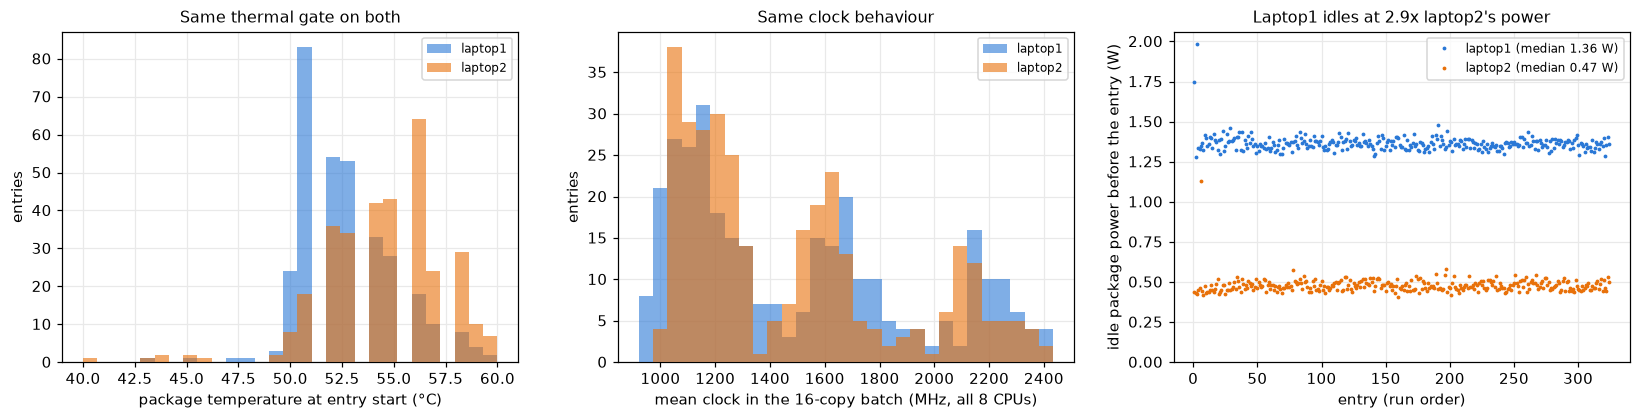

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
                     "axes.grid": True, "grid.color": "#e9e9e9", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures/compare_laptops"); FIG.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")


def short(q):
    return Path(q).stem


T, I, E = {}, {}, {}
for n in LAP:
    t = pd.read_csv(RUN[n] / f"query_timing_{DB}.csv")
    t["entry"] = (t["phase"].eq("warmup") & t["batch_index"].eq(1)).cumsum()
    t["round"] = (t["entry"] - 1) // 54 + 1
    T[n] = t
    i = pd.read_csv(RUN[n] / f"query_idle_{DB}.csv")
    i["entry"] = np.arange(1, len(i) + 1)
    I[n] = i
    m = t[t["phase"] == "measured"].pivot_table(index=["entry", "round", "query"], columns="batchnum",
                                                 values=["rapl_pkg_j", "rapl_core_j", "rapl_dram_j", "elapsed_sec",
                                                         "pkg_temp_start_c", "pkg_temp_mean_c", "mhz_mean"])
    e = pd.DataFrame({
        "pkg": (m["rapl_pkg_j"][16] - m["rapl_pkg_j"][1]) / 15,
        "core": (m["rapl_core_j"][16] - m["rapl_core_j"][1]) / 15,
        "dram": (m["rapl_dram_j"][16] - m["rapl_dram_j"][1]) / 15,
        "t": (m["elapsed_sec"][16] - m["elapsed_sec"][1]) / 15,
        "e1": m["rapl_pkg_j"][1], "t1": m["elapsed_sec"][1],
        "temp16": m["pkg_temp_mean_c"][16], "mhz16": m["mhz_mean"][16]}).reset_index()
    e["rest"] = e["pkg"] - e["core"]                         # uncore + GPU + everything in the package but the cores
    e["q"] = e["query"].map(short)
    e["kind"] = np.where(e["query"].str.contains("probe"), "probe", "sqlstorm")
    E[n] = e.merge(i[["entry", "idle_pkg_w", "idle_core_w", "idle_dram_w"]], on="entry")
    w1 = t[(t["phase"] == "warmup") & (t["batch_index"] == 1)].set_index("entry")
    E[n]["cold_t"] = E[n]["entry"].map(w1["elapsed_sec"])
    E[n]["start_c"] = E[n]["entry"].map(w1["pkg_temp_start_c"])
    print(f"{n}: {len(E[n])} entries, failed batches {int(t['failed'].sum())}, start temp "
          f"{E[n]['start_c'].min():.0f}–{E[n]['start_c'].max():.0f} °C, 16-copy clock median {E[n]['mhz16'].median():.0f} MHz, "
          f"idle package {I[n]['idle_pkg_w'].median():.2f} W")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
for ax, col, lbl in [(axes[0], "start_c", "package temperature at entry start (°C)"),
                     (axes[1], "mhz16", "mean clock in the 16-copy batch (MHz, all 8 CPUs)")]:
    b = np.linspace(min(E[n][col].min() for n in LAP), max(E[n][col].max() for n in LAP), 30)
    for n in LAP:
        ax.hist(E[n][col], bins=b, alpha=0.6, color=LCOL[n], label=n, zorder=3)
    ax.set_xlabel(lbl); ax.set_ylabel("entries"); ax.legend(fontsize=8)
axes[0].set_title("Same thermal gate on both", fontsize=10.5)
axes[1].set_title("Same clock behaviour", fontsize=10.5)
ax = axes[2]
for n in LAP:
    ax.plot(I[n]["entry"], I[n]["idle_pkg_w"], ".", ms=3, color=LCOL[n], label=f"{n} (median {I[n]['idle_pkg_w'].median():.2f} W)")
ax.set_xlabel("entry (run order)"); ax.set_ylabel("idle package power before the entry (W)"); ax.legend(fontsize=8)
ax.set_ylim(0, None)
ax.set_title(f"Laptop1 idles at {I['laptop1']['idle_pkg_w'].median() / I['laptop2']['idle_pkg_w'].median():.1f}x "
             f"laptop2's power", fontsize=10.5)
fig.tight_layout(); savefig(fig, "run_quality"); plt.show()

## 3. Energy and time per query

Each query has 6 slopes per machine (one per round). The ratio laptop2 / laptop1 of the mean slopes,
with a 95 % interval from the round-to-round spread on both machines (delta method).

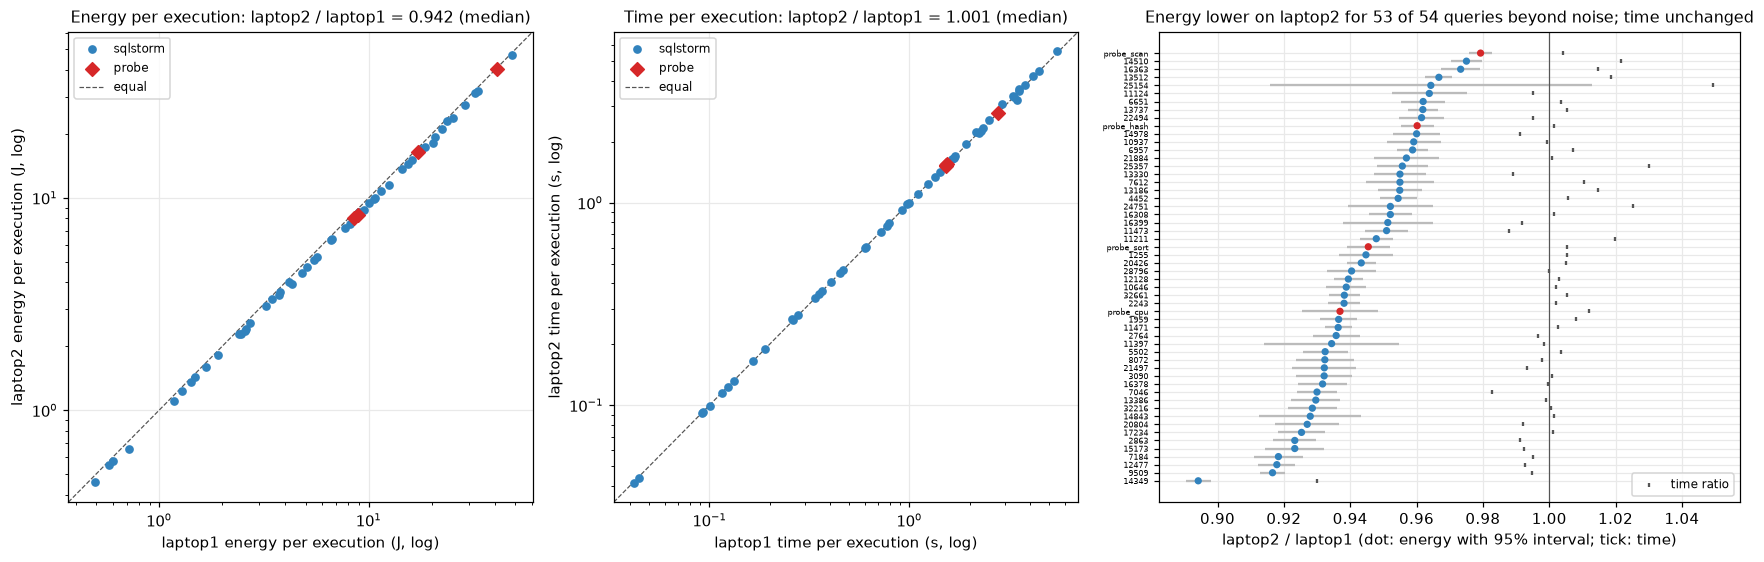

energy ratio laptop2/laptop1: median 0.942, range 0.894–0.979;  time ratio: median 1.001, range 0.930–1.049;  whole set: energy 0.948, time 1.004


In [4]:
def per_query(n, col):
    return E[n].groupby("q")[col].agg(["mean", "std", "size"])


PQ = {}
for col in ["pkg", "t", "core", "rest", "dram"]:
    a, b = per_query("laptop1", col), per_query("laptop2", col)
    r = b["mean"] / a["mean"]
    se = r * np.sqrt((a["std"] / a["mean"]) ** 2 / a["size"] + (b["std"] / b["mean"]) ** 2 / b["size"])
    PQ[col] = pd.DataFrame({"l1": a["mean"], "l2": b["mean"], "ratio": r, "lo": r - 1.96 * se, "hi": r + 1.96 * se,
                            "cv1": a["std"] / a["mean"], "cv2": b["std"] / b["mean"]})
KIND = E["laptop1"].groupby("q")["kind"].first()
R_E, R_T = PQ["pkg"]["ratio"], PQ["t"]["ratio"]
SIG_E = int(((PQ["pkg"]["hi"] < 1) | (PQ["pkg"]["lo"] > 1)).sum())

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1, 1, 1.25]})
for ax, col, unit, lbl in [(axes[0], "pkg", "J", "energy per execution"), (axes[1], "t", "s", "time per execution")]:
    d = PQ[col]
    for k, mk in [("sqlstorm", "o"), ("probe", "D")]:
        s = d[KIND == k]
        ax.scatter(s["l1"], s["l2"], s=22 if k == "sqlstorm" else 40, marker=mk,
                   color="#3182bd" if k == "sqlstorm" else "#d62728", label=k, zorder=3)
    lim = [d[["l1", "l2"]].min().min() * 0.8, d[["l1", "l2"]].max().max() * 1.25]
    ax.plot(lim, lim, color="#555", lw=0.8, ls="--", label="equal")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"laptop1 {lbl} ({unit}, log)"); ax.set_ylabel(f"laptop2 {lbl} ({unit}, log)"); ax.legend(fontsize=8)
    ax.set_title(f"{lbl.capitalize()}: laptop2 / laptop1 = {d['ratio'].median():.3f} (median)", fontsize=10.5)
ax = axes[2]
d = PQ["pkg"].sort_values("ratio")
y = np.arange(len(d))
ax.errorbar(d["ratio"], y, xerr=[d["ratio"] - d["lo"], d["hi"] - d["ratio"]], fmt="none", ecolor="#bbb", zorder=2)
ax.scatter(d["ratio"], y, s=14, color=np.where(KIND[d.index] == "probe", "#d62728", "#3182bd"), zorder=3)
ax.scatter(PQ["t"]["ratio"][d.index], y, s=10, marker="|", color="#555", zorder=3, label="time ratio")
ax.axvline(1, color="#555", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=5.5)
ax.set_xlabel("laptop2 / laptop1 (dot: energy with 95% interval; tick: time)"); ax.legend(fontsize=8, loc="lower right")
ax.set_title(f"Energy lower on laptop2 for {SIG_E} of {len(d)} queries beyond noise; time unchanged", fontsize=10.5)
fig.tight_layout(); savefig(fig, "per_query_ratio"); plt.show()
print(f"energy ratio laptop2/laptop1: median {R_E.median():.3f}, range {R_E.min():.3f}–{R_E.max():.3f};  "
      f"time ratio: median {R_T.median():.3f}, range {R_T.min():.3f}–{R_T.max():.3f};  "
      f"whole set: energy {E['laptop2']['pkg'].sum() / E['laptop1']['pkg'].sum():.3f}, "
      f"time {E['laptop2']['t'].sum() / E['laptop1']['t'].sum():.3f}")

## 4. Where the difference comes from

The package energy splits into the RAPL **core** domain and the **rest** of the package (uncore:
memory controller, last-level cache, ring, integrated GPU), plus **DRAM** as a separate domain. If
laptop2 simply draws a constant amount less power while busy, the energy gap of a query is that power
times its run time, `ΔE = ΔP · t`, and the ratio falls as `1 − ΔP / P` for low-power queries.

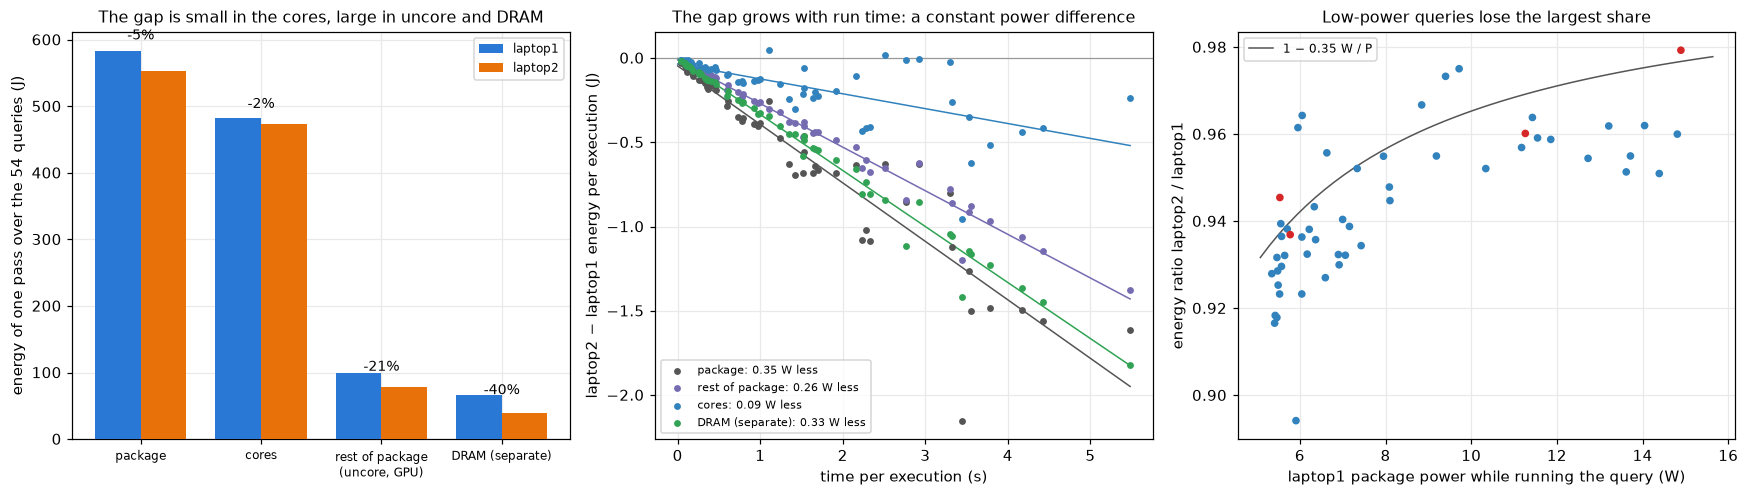

idle power before each entry (median W):
      laptop1  laptop2
pkg     1.360    0.473
core    0.170    0.084
rest    1.193    0.391
dram    0.583    0.256

energy, whole set laptop2/laptop1: pkg 0.948, core 0.982, rest 0.788, dram 0.595
power difference while running (fit of ΔE on time): pkg 0.347 W, core 0.088 W, rest 0.259 W, dram 0.332 W;  intercepts pkg -0.047 J, core -0.035 J, rest -0.011 J, dram -0.002 J
model 1 − ΔP/P vs measured ratio: r = 0.74


In [5]:
DOM = ["pkg", "core", "rest", "dram"]
DLBL = {"pkg": "package", "core": "cores", "rest": "rest of package\n(uncore, GPU)", "dram": "DRAM (separate)"}
SUMR = pd.Series({c: E["laptop2"][c].sum() / E["laptop1"][c].sum() for c in DOM})
IDLE = pd.DataFrame({n: {"pkg": I[n]["idle_pkg_w"].median(), "core": I[n]["idle_core_w"].median(),
                         "rest": (I[n]["idle_pkg_w"] - I[n]["idle_core_w"]).median(), "dram": I[n]["idle_dram_w"].median()}
                     for n in LAP})
both = PQ["pkg"][["l1", "l2"]].join(PQ["t"][["l1"]].rename(columns={"l1": "t"}))
X = np.c_[np.ones(len(both)), both["t"]]
FIT = {c: np.linalg.lstsq(X, (PQ[c]["l2"] - PQ[c]["l1"]).to_numpy(), rcond=None)[0] for c in DOM}
DP = {c: -FIT[c][1] for c in DOM}                                   # W less on laptop2 while running
P1 = PQ["pkg"]["l1"] / PQ["t"]["l1"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ax = axes[0]
x = np.arange(len(DOM)); w = 0.38
for j, n in enumerate(LAP):
    tot = [E[n][c].sum() / 6 for c in DOM]
    ax.bar(x + (j - 0.5) * w, tot, w, color=LCOL[n], label=n, zorder=3)
for i, c in enumerate(DOM):
    ax.text(i, max(E[n][c].sum() / 6 for n in LAP) * 1.03, f"{100 * (SUMR[c] - 1):+.0f}%", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([DLBL[c] for c in DOM], fontsize=8)
ax.set_ylabel("energy of one pass over the 54 queries (J)"); ax.legend(fontsize=8)
ax.set_title("The gap is small in the cores, large in uncore and DRAM", fontsize=10.5)
ax = axes[1]
for i, c in enumerate(["pkg", "rest", "core", "dram"]):
    d = PQ[c]["l2"] - PQ[c]["l1"]
    col = ["#555", "#756bb1", "#3182bd", "#31a354"][i]
    ax.scatter(both["t"], d, s=12, color=col, label=f"{DLBL[c].splitlines()[0]}: {DP[c]:.2f} W less", zorder=3)
    tt = np.linspace(0, both["t"].max(), 10)
    ax.plot(tt, FIT[c][0] + FIT[c][1] * tt, color=col, lw=1)
ax.axhline(0, color="#999", lw=0.8)
ax.set_xlabel("time per execution (s)"); ax.set_ylabel("laptop2 − laptop1 energy per execution (J)"); ax.legend(fontsize=7.5)
ax.set_title("The gap grows with run time: a constant power difference", fontsize=10.5)
ax = axes[2]
ax.scatter(P1, R_E, s=16, color=np.where(KIND[R_E.index] == "probe", "#d62728", "#3182bd"), zorder=3)
pp = np.linspace(P1.min() * 0.95, P1.max() * 1.05, 50)
ax.plot(pp, 1 - DP["pkg"] / pp, color="#555", lw=1, label=f"1 − {DP['pkg']:.2f} W / P")
ax.set_xlabel("laptop1 package power while running the query (W)"); ax.set_ylabel("energy ratio laptop2 / laptop1")
ax.legend(fontsize=8)
ax.set_title("Low-power queries lose the largest share", fontsize=10.5)
fig.tight_layout(); savefig(fig, "where_from"); plt.show()

print("idle power before each entry (median W):")
print(IDLE.round(3).to_string())
print("\nenergy, whole set laptop2/laptop1: " + ", ".join(f"{c} {SUMR[c]:.3f}" for c in DOM))
print("power difference while running (fit of ΔE on time): " + ", ".join(f"{c} {DP[c]:.3f} W" for c in DOM)
      + f";  intercepts {', '.join(f'{c} {FIT[c][0]:+.3f} J' for c in DOM)}")
corr = np.corrcoef(1 - DP["pkg"] / P1, R_E)[0, 1]
print(f"model 1 − ΔP/P vs measured ratio: r = {corr:.2f}")

## 5. Repeatability and drift

The machine gap only matters if it is larger than each machine's own repeat noise. Left: the
round-to-round coefficient of variation of each query's slope. Right: each round's slopes relative to
the query's session mean — a drift over the 3.4 h session would show as a trend.

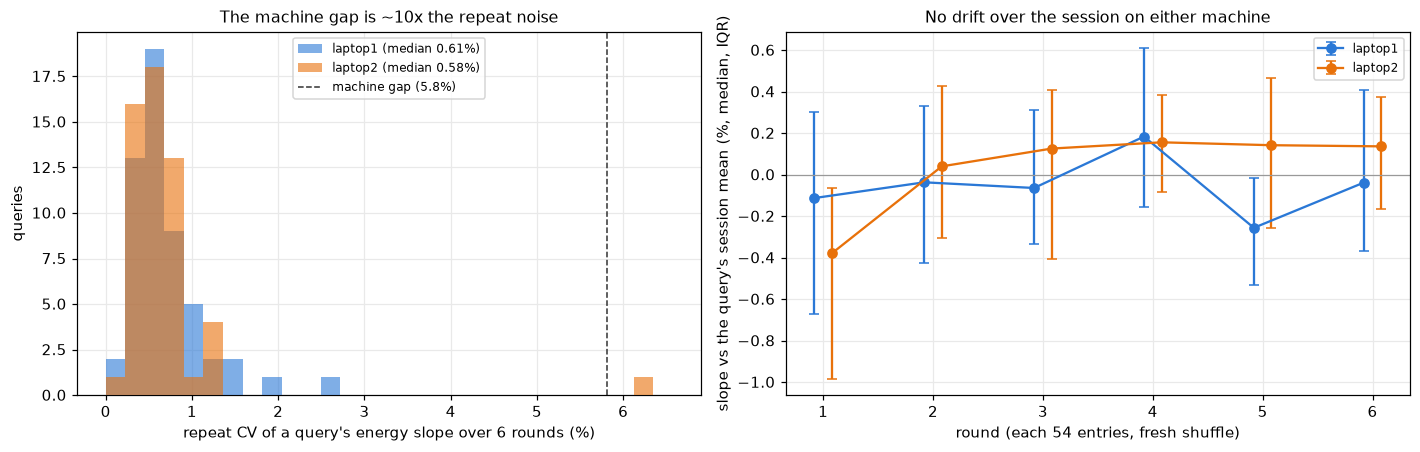

laptop1: round medians -0.11%, -0.04%, -0.06%, +0.18%, -0.26%, -0.04%
laptop2: round medians -0.38%, +0.04%, +0.13%, +0.16%, +0.14%, +0.14%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
b = np.linspace(0, max(PQ["pkg"][["cv1", "cv2"]].max().max(), 0.01) * 100 * 1.05, 30)
for n, c in [("laptop1", "cv1"), ("laptop2", "cv2")]:
    ax.hist(100 * PQ["pkg"][c], bins=b, alpha=0.6, color=LCOL[n], label=f"{n} (median {100 * PQ['pkg'][c].median():.2f}%)", zorder=3)
gap = 100 * (1 - R_E.median())
ax.axvline(gap, color="#333", ls="--", lw=1, label=f"machine gap ({gap:.1f}%)")
ax.set_xlabel("repeat CV of a query's energy slope over 6 rounds (%)"); ax.set_ylabel("queries"); ax.legend(fontsize=8)
ax.set_title(f"The machine gap is ~{gap / (100 * PQ['pkg'][['cv1', 'cv2']].median().mean()):.0f}x the repeat noise",
             fontsize=10.5)
ax = axes[1]
DRIFT = {}
for n in LAP:
    e = E[n].copy()
    e["rel"] = e["pkg"] / e.groupby("q")["pkg"].transform("mean") - 1
    g = e.groupby("round")["rel"].agg(["median", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
    g.columns = ["med", "q25", "q75"]
    DRIFT[n] = g
    ax.errorbar(g.index + (0.08 if n == "laptop2" else -0.08), 100 * g["med"],
                yerr=[100 * (g["med"] - g["q25"]), 100 * (g["q75"] - g["med"])], fmt="o-", color=LCOL[n], label=n, capsize=3)
ax.axhline(0, color="#999", lw=0.8)
ax.set_xlabel("round (each 54 entries, fresh shuffle)"); ax.set_ylabel("slope vs the query's session mean (%, median, IQR)")
ax.legend(fontsize=8)
ax.set_title("No drift over the session on either machine", fontsize=10.5)
fig.tight_layout(); savefig(fig, "repeatability"); plt.show()
for n in LAP:
    print(f"{n}: round medians " + ", ".join(f"{100 * v:+.2f}%" for v in DRIFT[n]["med"]))

## 6. Same execution? And the costs paid once per entry

PostgreSQL's own statistics of every measured copy (from `EXPLAIN ANALYZE`, SQLStorm queries only — the
probes run without it): if the plans, rows and buffer use match, the queries did the same work on both
machines. Then the costs outside the slope: the fixed per-batch cost `E1 − slope`, and the first
warm-up after the cold start, which reads the tables from disk.

SQLStorm queries with samples on both: 50;  identical medians per statistic: workers 50/50, nodes 49/50, rows 50/50, processed 44/50, hit 50/50, read 50/50, temp 49/50
server execution time laptop2/laptop1: median 1.004, range 0.930–1.029
queries whose plan statistics differ (workers, nodes, rows, buffers, temp): ['13512', '22494']
         exec_ms                hit            nodes           processed                read             rows              temp          workers        
         laptop1   laptop2  laptop1  laptop2 laptop1 laptop2     laptop1     laptop2 laptop1 laptop2  laptop1  laptop2  laptop1  laptop2 laptop1 laptop2
q                                                                                                                                                       
13512  5458.9905  5544.861  58686.0  58686.0    17.0    17.0  25088031.0  25088031.0     0.0     0.0  16071.0  16071.0  58439.0  58438.0     2.0     2.0
22494  1100.9225  1097.428  78784.0  78784.0    21.0  

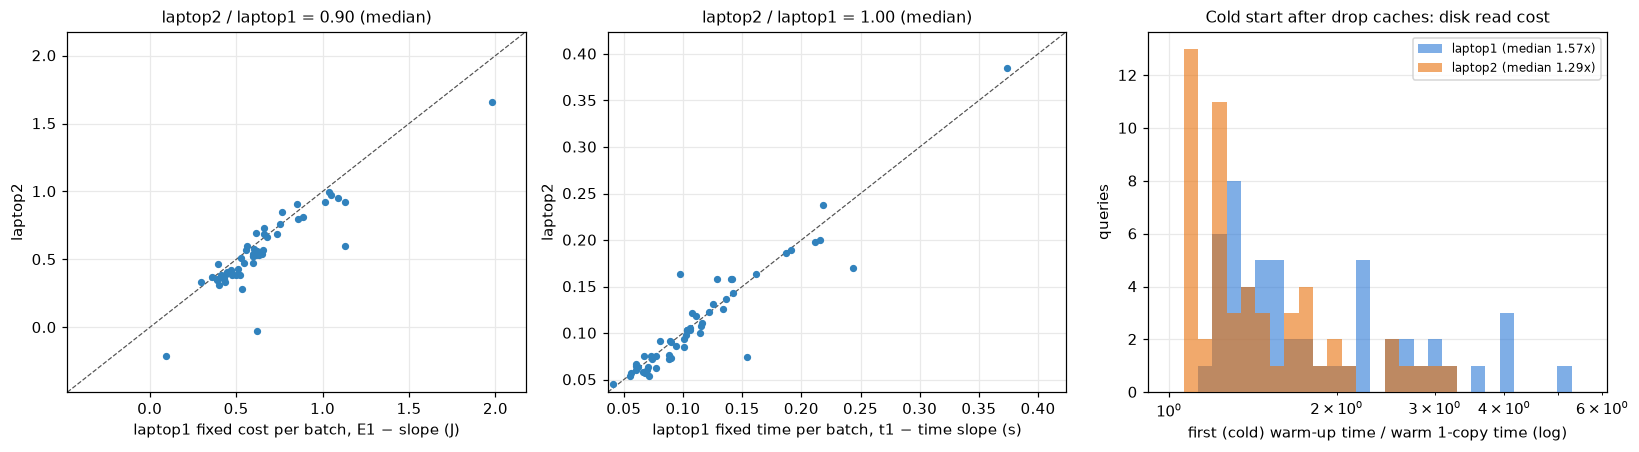

extra time of the cold warm-up, laptop2/laptop1: median 0.47


In [7]:
SMP = {}
for n in LAP:
    s = pd.read_csv(RUN[n] / f"query_samples_{DB}.csv")
    s = s[(s["phase"] == "measured") & ~s["query"].str.contains("probe")].copy()
    s["q"] = s["query"].map(short)
    SMP[n] = s.groupby("q").agg(workers=("workers_launched", "median"), nodes=("plan_nodes", "median"),
                                rows=("rows_out", "median"), processed=("rows_processed", "median"),
                                hit=("shared_hit_blks", "median"), read=("shared_read_blks", "median"),
                                temp=("temp_written_blks", "median"), exec_ms=("server_execution_ms", "median"))
s1, s2 = SMP["laptop1"].align(SMP["laptop2"], join="inner")
EXEC_SAME = pd.Series({c: int((s1[c] == s2[c]).sum()) for c in ["workers", "nodes", "rows", "processed", "hit", "read", "temp"]})
EXEC_R = (s2["exec_ms"] / s1["exec_ms"])
EXEC_DIFF = s1.index[(s1[["workers", "nodes", "rows", "hit", "read", "temp"]] != s2[["workers", "nodes", "rows", "hit", "read", "temp"]]).any(axis=1)]
print(f"SQLStorm queries with samples on both: {len(s1)};  identical medians per statistic: "
      + ", ".join(f"{k} {v}/{len(s1)}" for k, v in EXEC_SAME.items()))
print(f"server execution time laptop2/laptop1: median {EXEC_R.median():.3f}, range {EXEC_R.min():.3f}–{EXEC_R.max():.3f}")
print(f"queries whose plan statistics differ (workers, nodes, rows, buffers, temp): {list(EXEC_DIFF) or 'none'}")
if len(EXEC_DIFF):
    print(pd.concat({"laptop1": s1.loc[EXEC_DIFF], "laptop2": s2.loc[EXEC_DIFF]}, axis=1).swaplevel(axis=1).sort_index(axis=1).to_string())

FX = {}
for n in LAP:
    g = E[n].groupby("q")
    FX[n] = pd.DataFrame({"F": g.apply(lambda x: (x["e1"] - x["pkg"]).mean(), include_groups=False),
                          "Ft": g.apply(lambda x: (x["t1"] - x["t"]).mean(), include_groups=False),
                          "cold": g["cold_t"].mean(), "warm": g["t1"].mean()})
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, lbl in [(axes[0], "F", "fixed cost per batch, E1 − slope (J)"),
                     (axes[1], "Ft", "fixed time per batch, t1 − time slope (s)")]:
    ax.scatter(FX["laptop1"][col], FX["laptop2"][col], s=14, color="#3182bd", zorder=3)
    lim = [min(FX[n][col].min() for n in LAP) * 0.9, max(FX[n][col].max() for n in LAP) * 1.1]
    ax.plot(lim, lim, color="#555", lw=0.8, ls="--"); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"laptop1 {lbl}"); ax.set_ylabel("laptop2")
    ax.set_title(f"laptop2 / laptop1 = {(FX['laptop2'][col] / FX['laptop1'][col]).median():.2f} (median)", fontsize=10.5)
ax = axes[2]
cr = {n: FX[n]["cold"] / FX[n]["warm"] for n in LAP}
b = np.logspace(0, np.log10(max(c.max() for c in cr.values()) * 1.1), 30)
for n in LAP:
    ax.hist(cr[n], bins=b, alpha=0.6, color=LCOL[n], label=f"{n} (median {cr[n].median():.2f}x)", zorder=3)
ax.set_xscale("log"); ax.set_xlabel("first (cold) warm-up time / warm 1-copy time (log)"); ax.set_ylabel("queries")
ax.legend(fontsize=8)
ax.set_title("Cold start after drop caches: disk read cost", fontsize=10.5)
fig.tight_layout(); savefig(fig, "fixed_costs"); plt.show()
COLD_R = (FX["laptop2"]["cold"] - FX["laptop2"]["warm"]) / (FX["laptop1"]["cold"] - FX["laptop1"]["warm"])
print(f"extra time of the cold warm-up, laptop2/laptop1: median {COLD_R.median():.2f}")

## 7. Summary

In [8]:
from IPython.display import Markdown, display
OUT = PQ["pkg"][["l1", "l2", "ratio", "lo", "hi", "cv1", "cv2"]].rename(columns=lambda c: f"energy_{c}").join(
      PQ["t"][["l1", "l2", "ratio"]].rename(columns=lambda c: f"time_{c}")).join(
      pd.concat({c: PQ[c]["ratio"] for c in ["core", "rest", "dram"]}, axis=1).add_suffix("_ratio"))
OUT.insert(0, "kind", KIND)
OUT.index.name = "query"
OUT.round(5).to_csv("csv/compare_laptops_per_query.csv")

diffs = [d for d in DIFF.index[~DIFF["same"]] if d not in ("host", "session date (UTC)", "PG18 port",
                                                            "apt timers paused by the script", "PostgreSQL clusters online")]
lines = [
    f"* **Same test, verified:** order file, all {len(QMD5['laptop1'])} query/probe files, PostgreSQL "
    f"{', '.join(map(str, sorted(set(RI['laptop1']['pg_version']))))}, testing parameters, database and run "
    f"parameters are identical ({int(SAME['same'].sum())}/{len(SAME)} checks). Both sessions: 324/324 entries, no failures, "
    f"no drift over the rounds.",
    f"* **Time is the same:** laptop2/laptop1 time per execution {R_T.median():.3f} (median), PostgreSQL execution "
    f"time {EXEC_R.median():.3f}; plans, rows and buffer use are identical for {len(s1) - len(EXEC_DIFF)} of {len(s1)} "
    f"SQLStorm queries" + (f" ({', '.join(EXEC_DIFF)} differ)." if len(EXEC_DIFF) else "."),
    f"* **Energy is not:** laptop2 uses {100 * (1 - R_E.median()):.1f}% less package energy per execution (median; "
    f"range {100 * (1 - R_E.max()):.1f}–{100 * (1 - R_E.min()):.1f}%), lower for {SIG_E} of {len(R_E)} queries beyond "
    f"noise. Repeat noise on each machine is {100 * PQ['pkg']['cv1'].median():.2f}% / {100 * PQ['pkg']['cv2'].median():.2f}%.",
    f"* **It is a constant power offset, mostly outside the cores:** {DP['pkg']:.2f} W less while running "
    f"({DP['rest']:.2f} W uncore/GPU, {DP['core']:.2f} W cores); DRAM {100 * (1 - SUMR['dram']):.0f}% lower. "
    f"Idle: {IDLE.at['pkg', 'laptop1']:.2f} W vs {IDLE.at['pkg', 'laptop2']:.2f} W package. Low-power queries "
    f"therefore differ most (`1 − ΔP/P`, r = {corr:.2f}).",
    f"* **Likely causes (machine differences):** {', '.join(diffs)}. Laptop1 runs without the i915 graphics driver "
    f"(`nomodeset`) and with OS microcode loading disabled (`dis_ucode_ldr`): an iGPU that is never put to sleep "
    f"fits the higher idle and uncore power. Twice the memory fits the higher DRAM energy. These are consistent with "
    f"the data but not tested one at a time.",
    f"* **For the data:** energy measured on laptop1 is ~{100 * (1 / R_E.median() - 1):.0f}% higher than on laptop2 "
    f"for the same query; the full laptop2 export is the lower-power machine.",
]
display(Markdown("\n".join(lines)))

* **Same test, verified:** order file, all 54 query/probe files, PostgreSQL 18.6, testing parameters, database and run parameters are identical (16/16 checks). Both sessions: 324/324 entries, no failures, no drift over the rounds.
* **Time is the same:** laptop2/laptop1 time per execution 1.001 (median), PostgreSQL execution time 1.004; plans, rows and buffer use are identical for 48 of 50 SQLStorm queries (13512, 22494 differ).
* **Energy is not:** laptop2 uses 5.8% less package energy per execution (median; range 2.1–10.6%), lower for 53 of 54 queries beyond noise. Repeat noise on each machine is 0.61% / 0.58%.
* **It is a constant power offset, mostly outside the cores:** 0.35 W less while running (0.26 W uncore/GPU, 0.09 W cores); DRAM 40% lower. Idle: 1.36 W vs 0.47 W package. Low-power queries therefore differ most (`1 − ΔP/P`, r = 0.74).
* **Likely causes (machine differences):** memory, disk, BIOS, microcode, kernel, kernel command line, graphics driver. Laptop1 runs without the i915 graphics driver (`nomodeset`) and with OS microcode loading disabled (`dis_ucode_ldr`): an iGPU that is never put to sleep fits the higher idle and uncore power. Twice the memory fits the higher DRAM energy. These are consistent with the data but not tested one at a time.
* **For the data:** energy measured on laptop1 is ~6% higher than on laptop2 for the same query; the full laptop2 export is the lower-power machine.